In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/PTDLKD/Train.csv",index_col = 0)

In [ ]:
df.head(5)

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
ID,,,,,,,,,,,
1,D,Flight,4,2,177,3,low,F,44,1233,1
2,F,Flight,4,5,216,2,low,M,59,3088,1
3,A,Flight,2,2,183,4,low,M,48,3374,1
4,B,Flight,3,3,176,4,medium,M,10,1177,1
5,C,Flight,2,2,184,3,medium,F,46,2484,1


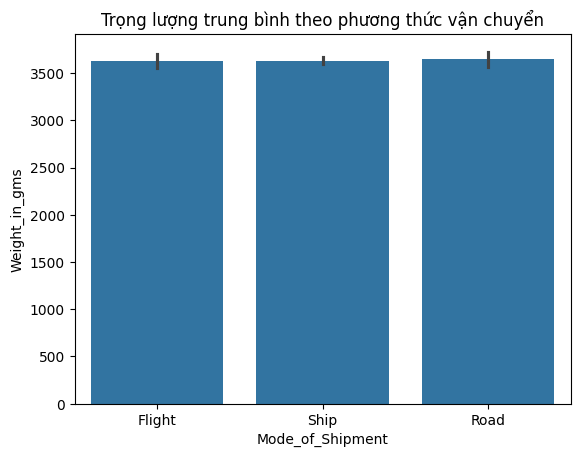

In [ ]:
sns.barplot(data=df, x='Mode_of_Shipment', y='Weight_in_gms')
plt.title("Trọng lượng trung bình theo phương thức vận chuyển")
plt.show()


**Nhận xét:**

- Trọng lượng trung bình **tương đối tương đương** giữa các phương thức(3600gr)
- Flight không chỉ dành cho hàng nhẹ như các giả định thường gặp

**Insight rút ra:** sự phân bổ vận chuyển **không bị giới hạn bởi trọng lượng**, mà có thể dựa vào yếu tố khác như thời gian giao hàng, chi phí, hoặc địa lý.



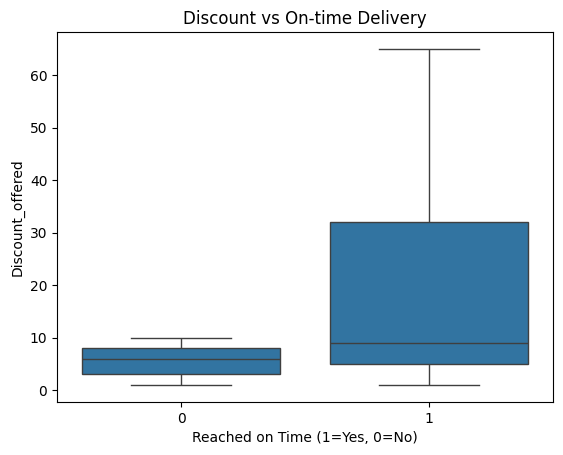

In [ ]:
sns.boxplot(data=df, x='Reached.on.Time_Y.N', y='Discount_offered'); plt.title('Discount vs On-time Delivery'); plt.xlabel('Reached on Time (1=Yes, 0=No)'); plt.show()

**Nhận xét:**
- Biểu đồ so sánh mức giảm giá (Discount_offered) giữa hai nhóm đơn hàng (0 = Giao trễ, 1 = Giao đúng giờ)
- Nhóm giao đúng giờ (1) có:
  - **Khoảng phân bố giảm giá rộng** (từ 0 đến ~65%)
  - Median cao hơn rõ rệt (~10%)
  - Nhiều đơn được giảm giá sâu (>30%)
- Nhóm giao trễ (0):
  - Có mức giảm giá rất thấp, hầu hết chỉ quanh 5- 10%
  -Khoảng phân bố hẹp và median thấp hơn đáng kể

**Insight rút ra:**
- Có sự tương quan mạnh mẽ giữa việc giao hàng đúng hạn và mức giảm giá:
  - Công ty có thể đang ưu đãi nhiều hơn cho các đơn đúng giờ, như một phần của chiến lược kích thích nhu cầu.
  - Hoặc ngược lại: việc giảm giá cao có thể giúp đảm bảo việc giao hàng đúng hẹn thông qua ưu tiên xử lý.
  - Trong khi đó, các đơn giao trễ lại ít được giảm giá, điều này có thể gây ra sự không công bằng từ góc nhìn khách hàng.

** Đề xuất hành động:**
- Rà soát lại chính sách ưu đãi giảm giá:
  -  Nếu mục tiêu là giữ chân khách hàng sau trải nghiệm kém (giao hàng trễ), thì nên áp dụng giảm giá nhiều hơn cho nhóm này.
  - Hoặc, nếu giảm giá đang được dùng như công cụ để đảm bảo cam kết giao đúng hạn, cần làm rõ thông điệp đến khách hàng
- Phân tích hiệu quả giảm giá theo từng nhóm (giao đúng/trễ) để xác định chiến lược tối ưu hóa chi phí & trải nghiệm khách hàng.


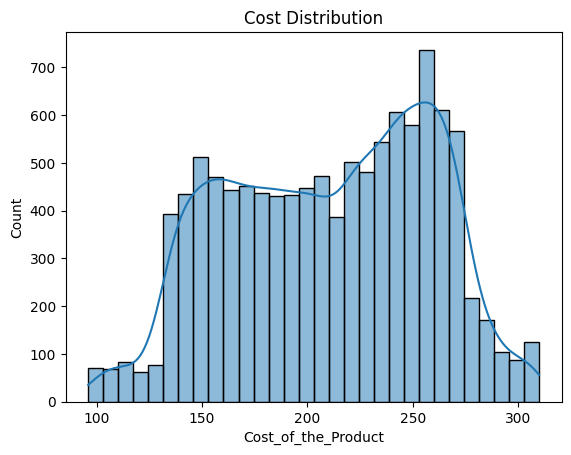

In [ ]:
sns.histplot(data=df, x='Cost_of_the_Product', kde=True); plt.title('Cost Distribution'); plt.show()


**Nhận xét:**

- Chi phí sản phẩm có xu hướng phân bố lệch phải (right-skewed).
- Phần lớn sản phẩm có chi phí dao động trong khoảng 150 - 275.
- Đỉnh phân phối rơi vào khoảng 250.
- Một số sản phẩm có chi phí thấp (vào khoảng 100) và ít có sản phẩm vượt mức hơn 300.
**Insight:**
- Các sản phẩm hiện tại chủ yếu nằm trong phân khúc giá tầm trung và các công ty đang cung cấp sản phẩm chủ yếu ở phân khúc này (~250 USD);
- Mức giá giữa các sản phẩm không chênh lệch nhiều
- Có thể chia sản phẩm thành 3 nhóm giá:
   - Giá rẻ: dưới 150 USD
   - Tầm trung: từ 150–275 USD
   - Cao cấp: trên 275 USD

** Đề xuất: **
Rà soát và xem thử lại giá bán của những sản phẩm ít được khách hàng lựa chọn – đặc biệt là các sản phẩm ở phân khúc giá quá rẻ hoặc quá đắt.
Tăng cường marketing, quảng bá cho nhóm sản phẩm tầm trung, vì đây là nhóm phổ biến nhất và phù hợp với số đông khách hàng hiện tại.


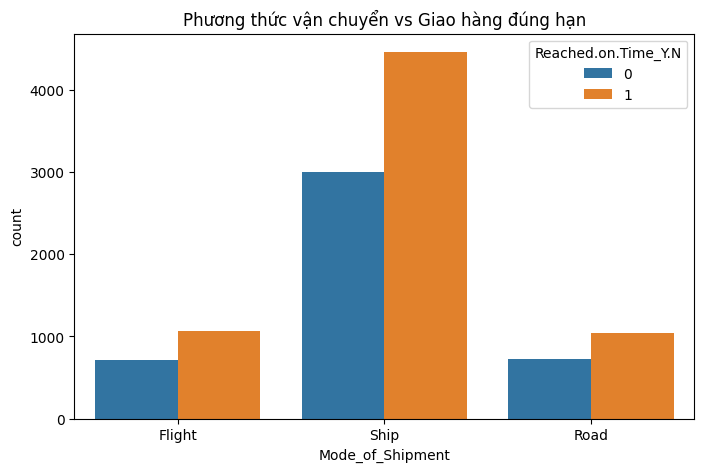

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Mode_of_Shipment", hue="Reached.on.Time_Y.N")
plt.title("Phương thức vận chuyển vs Giao hàng đúng hạn")
plt.show()

**Nhận xét:**

- Ship (tàu) là phương thức được sử dụng nhiều nhất và có tỷ lệ giao đúng hạn cao hơn hẳn so với trễ.


- Flight (máy bay) và Road (đường bộ) có lượng giao hàng ít hơn và tỷ lệ giao đúng hạn thấp hơn so với Ship.

**Insight rút ra:**

- Phần lớn đơn hàng được vận chuyển bằng đường thủy, cho thấy doanh nghiệp đang ưu tiên hình thức này.


- Tuy nhiên, số lượng giao hàng trễ ở phương thức này cũng cao, cần đánh giá lại hiệu suất của từng phương thức vận chuyển.


/tmp/ipython-input-32-1917313268.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=warehouse_on_time, x="Warehouse_block", y="Reached.on.Time_Y.N", palette="Blues_d")


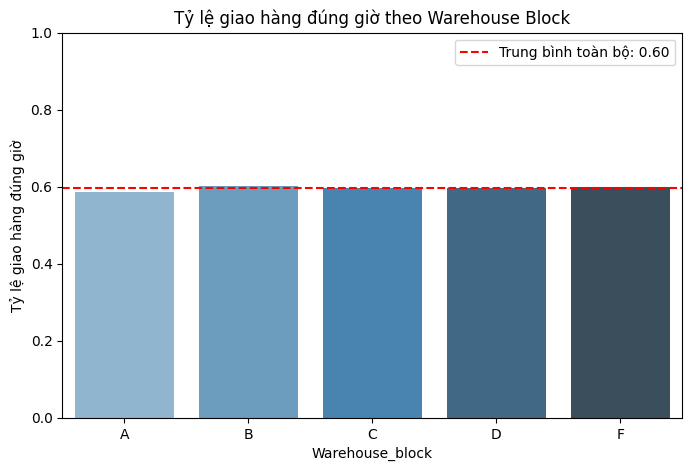

In [ ]:
# Tính tỷ lệ giao đúng giờ theo từng Warehouse_block
warehouse_on_time = df.groupby("Warehouse_block")["Reached.on.Time_Y.N"].mean().reset_index()

# Tính trung bình toàn bộ
global_avg = df["Reached.on.Time_Y.N"].mean()

# Vẽ biểu đồ
plt.figure(figsize=(8,5))
sns.barplot(data=warehouse_on_time, x="Warehouse_block", y="Reached.on.Time_Y.N", palette="Blues_d")
plt.axhline(global_avg, color='red', linestyle='--', label=f'Trung bình toàn bộ: {global_avg:.2f}')
plt.ylabel("Tỷ lệ giao hàng đúng giờ")
plt.title("Tỷ lệ giao hàng đúng giờ theo Warehouse Block")
plt.ylim(0, 1)
plt.legend()
plt.show()

**Nhận xét**

Tỷ lệ giao đúng giờ các warehouse gần bằng nhau (~60%) → không có block nào vượt trội rõ rệt.

Hiệu suất chung thấp → chỉ 60% giao đúng giờ, cần cải thiện toàn hệ thống.

**Insight**
Warehouse_block không phải yếu tố quyết định chính → cần phân tích yếu tố khác như Mode_of_Shipment, Discount_offered, Weight_in_gms.

 **Đề xuất:**


Duy trì đồng đều giữa các warehouse, tối ưu từ khâu khác.

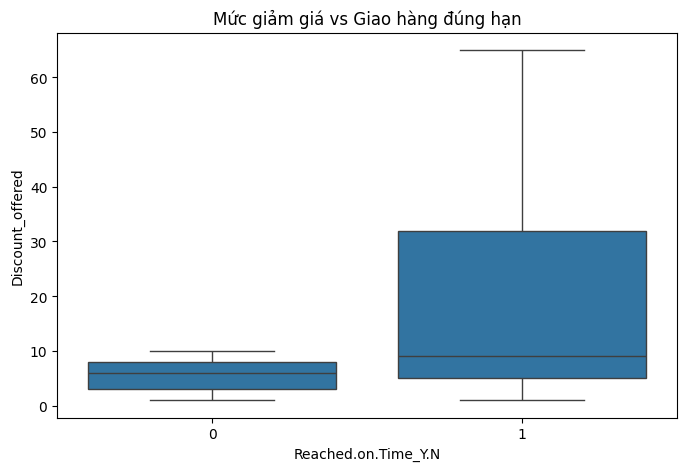

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Reached.on.Time_Y.N", y="Discount_offered")
plt.title("Mức giảm giá vs Giao hàng đúng hạn")
plt.show()

**Nhận xét:**

-Sự chênh lệch rõ rệt về mức giảm giá giữa hai nhóm đơn hàng


  - Nhóm đơn hàng được giao không đúng hạn (0) có mức giảm giá thấp, với trung vị khoảng 6–7 đơn vị, và hiếm khi vượt quá 10.


  - Trong khi đó, nhóm giao đúng hạn (1) có sự phân bố mức giảm giá rất rộng, trung vị cao hơn (~9–10), và có nhiều trường hợp mức giảm giá rất cao (lên đến hơn 60 đơn vị).


-Biến động lớn trong nhóm giao đúng hạn


- Khoảng phân bố (IQR) của mức giảm giá ở nhóm giao đúng hạn rộng hơn rất nhiều so với nhóm giao trễ, cho thấy chính sách giảm giá có xu hướng được sử dụng đa dạng hơn khi đảm bảo giao đúng hạn.


-Không có outlier trong nhóm giao trễ


- Dữ liệu nhóm giao không đúng hạn khá “ổn định”, không có ngoại lệ lớn, cho thấy mức giảm giá ở nhóm này được kiểm soát chặt chẽ hơn.



**Insight rút ra:**
- Doanh nghiệp có xu hướng áp dụng mức giảm giá cao hơn cho các đơn hàng giao đúng hạn, điều này có thể phản ánh:


- Chiến lược kích cầu cho nhóm sản phẩm/dịch vụ có khả năng giao hàng tốt.


- Các chương trình khuyến mãi tập trung vào việc đẩy nhanh tốc độ giao hàng và duy trì cam kết với khách hàng.


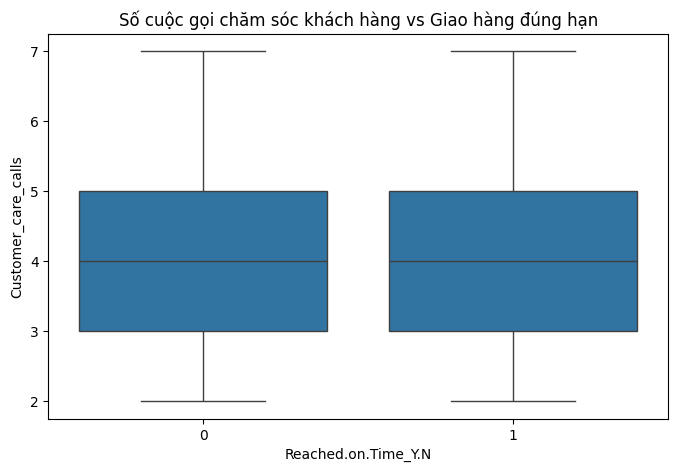

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Reached.on.Time_Y.N", y="Customer_care_calls")
plt.title("Số cuộc gọi chăm sóc khách hàng vs Giao hàng đúng hạn")
plt.show()


**Nhận xét:**

- Số cuộc gọi chăm sóc khách hàng gần như không khác biệt giữa hai nhóm: giao hàng đúng hạn (1) và không đúng hạn (0).


- Trung vị đều là 4 cuộc gọi, và phân bố giống nhau.

**Insight rút ra:**

- Số lượng cuộc gọi chăm sóc khách hàng không có sự khác biệt rõ rệt giữa hai nhóm giao hàng đúng hạn và trễ.


- Việc tăng số cuộc gọi chưa chắc cải thiện được hiệu quả giao hàng, nên tập trung xử lý nguyên nhân cốt lõi từ vận hành.


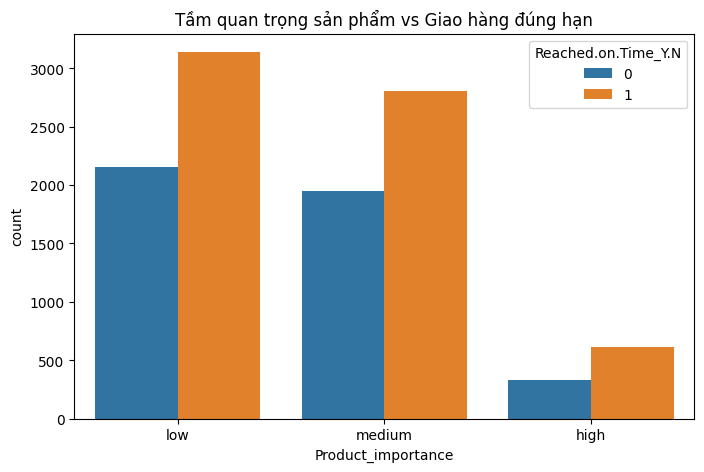

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Product_importance", hue="Reached.on.Time_Y.N")
plt.title("Tầm quan trọng sản phẩm vs Giao hàng đúng hạn")
plt.show()

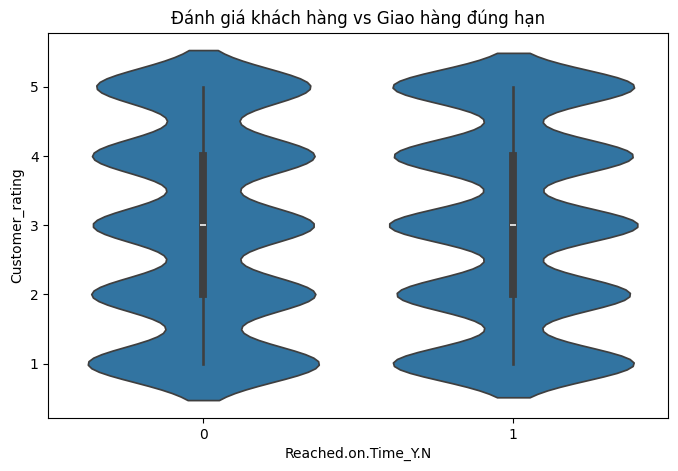

In [ ]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x="Reached.on.Time_Y.N", y="Customer_rating")
plt.title("Đánh giá khách hàng vs Giao hàng đúng hạn")
plt.show()


**Nhận xét:**

-Phân bố đánh giá khách hàng gần như tương đồng giữa hai nhóm:


- Cả hai nhóm giao không đúng hạn (0) và giao đúng hạn (1) đều có phân bố đánh giá khách hàng trải dài từ 1 đến 5, với trung vị nằm quanh mức 3.


- Hình dạng violin khá đối xứng cho cả hai nhóm, cho thấy không có sự khác biệt đáng kể trong phân bố đánh giá.


-Mức độ hài lòng không bị ảnh hưởng rõ rệt bởi việc giao hàng đúng hạn:


- Mặc dù có thể kỳ vọng rằng việc giao hàng đúng hạn sẽ cải thiện đánh giá, tuy nhiên biểu đồ cho thấy đánh giá của khách hàng không bị ảnh hưởng nhiều bởi yếu tố này.


- Hai đồ thị gần như giống hệt nhau về hình dạng và mật độ.



**Insight rút ra:**
-Yếu tố giao hàng đúng hạn chưa chắc là nhân tố quyết định chính đối với mức độ hài lòng của khách hàng.


- Khách hàng có thể đánh giá dựa trên nhiều yếu tố khác như chất lượng sản phẩm, chăm sóc khách hàng, giá cả, v.v.


- Việc giao trễ không kéo theo đánh giá thấp một cách đáng kể, như giả định thông thường.


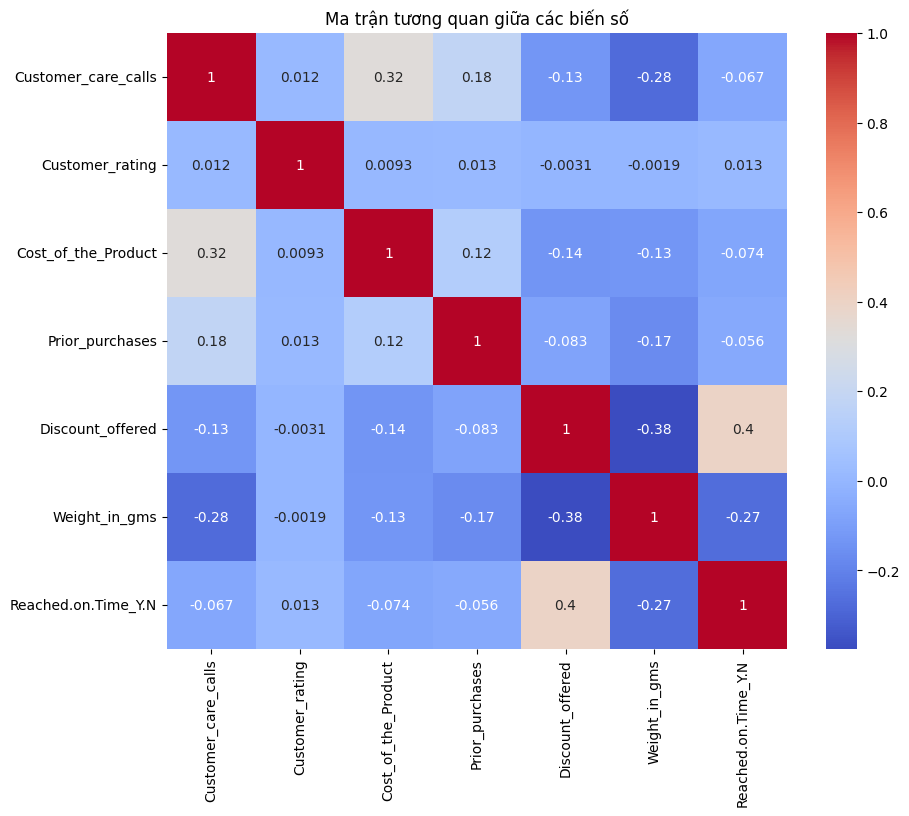

In [ ]:
corr = df[["Customer_care_calls", "Customer_rating", "Cost_of_the_Product", "Prior_purchases", "Discount_offered", "Weight_in_gms", "Reached.on.Time_Y.N"]].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Ma trận tương quan giữa các biến số")
plt.show()


**Nhận xét:**

- Hai yếu tố ảnh hưởng mạnh nhất đến việc giao hàng đúng hạn (Reached.on.Time_Y.N):

  - Discount offered (+0.40) → càng giảm giá cao thì càng dễ giao đúng hạn

 - Weight in gms (–0.27) → hàng càng nặng thì càng dễ bị giao trễ

- Các biến còn lại có tương quan yếu hoặc không đáng kể với Reached.on.Time_Y.N:

   - Customer care calls, Prior purchases, Customer rating, Cost of the Product đều có hệ số gần 0 (|r| < 0.1)

- Mối quan hệ đáng chú ý giữa các biến khác:

  - Customer care calls và - Cost of the Product (+0.32) → có thể sản phẩm đắt hơn khiến khách gọi CSKH nhiều hơn

Discount_offered và Weight in gms (–0.38) → hàng càng nhẹ thì càng được giảm giá nhiều hơn


**Insight rút ra **
- Chỉ có Discount offered và Weight in gms là hai biến có ảnh hưởng rõ rệt đến khả năng giao hàng đúng hạn. Các biến còn lại có mức tương quan thấp và không đáng kể để phân tích sâu hơn.
- Tập trung tối ưu 2 yếu tố quan trọng nhất ảnh hưởng đến khả năng giao hàng đúng hạn:
→ Mức giảm giá (tăng hỗ trợ)
→ Trọng lượng hàng hóa (giảm rủi ro trễ)
Đồng thời, tự động hóa phân tích rủi ro đơn hàng theo trọng lượng và mức giảm giá để phân bổ tài nguyên vận chuyển hiệu quả hơn.




